In [17]:
import os
import re
import ast
import math
import time
import shutil
import random
import requests
import unicodedata

from collections import Counter, defaultdict
from urllib.parse import quote
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Polygon
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

import networkx as nx
from tqdm import tqdm_notebook
from PIL import Image

from bs4 import BeautifulSoup
from selenium import webdriver
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.common.by import By

import pytesseract
import sympy
from bing_image_downloader.downloader import download

from nltk.stem import WordNetLemmatizer
from nltk import pos_tag, word_tokenize
from nltk.corpus import stopwords, wordnet

import scipy.stats as stats
import scipy.stats as sstats  # 둘 다 쓰는 경우 유지, 아니라면 하나로 통일

from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import spearmanr, pearsonr

import plotly.graph_objects as go

import word2image as w2i

In [18]:
def resize_and_save(image_path, save_dir, pixel_count, keyword=None):    
    """
    Resize and save a specific image or all images in a directory.

    Parameters:
        image_path (str): Path to the original image directory.
        save_dir (str): Path to the directory where resized images will be saved.
        pixel_count (int): Total pixel count for resizing.
        keyword (str, optional): If provided, only the image with this keyword will be processed. 
                                 If None, all images in the directory will be processed.
    """
    
    # Ensure the save directory exists
    os.makedirs(save_dir, exist_ok=True)

    # Generate the list of files to process
    if keyword:
        # Process a specific keyword image
        image_files = [f"{keyword}.png"]
    else:
        # Process all images in the directory
        image_files = [f for f in os.listdir(image_path) if f.endswith((".png", ".jpg", ".jpeg"))]
    
    if not image_files:
        print(f"No images found in {image_path}.")
        return

    for image_file in image_files:
        image_file_path = os.path.join(image_path, image_file)

        if not os.path.exists(image_file_path):
            print(f"{image_file_path} does not exist.")
            continue

        # Open the image
        with Image.open(image_file_path) as img:
            width, height = img.size
            ratio = max(width, height) / min(width, height)
            
            # Solve for new size based on the given pixel count
            x = sympy.symbols("x")
            f = sympy.Eq(x * (x / ratio), pixel_count)
            new_size = sympy.solve(f)[1]
            new_width, new_height = (int(new_size / ratio), int(new_size)) if width < height else (int(new_size), int(new_size / ratio))
            
            # Resize the image
            resized_img = img.resize((new_width, new_height))
            
            # Save the resized image
            resized_image_path = os.path.join(save_dir, image_file)
            resized_img.save(resized_screenshot_path)
            
            print(f"Resized screenshot saved to {resized_iamge_path}")
"""
These functions are used to extract the first, second, or third element from each sublist 
in a list of lists, where each sublist contains three elements.
"""

def leave_last_element(List):
    lst=[]    
    for x in List:
            lst.append(x[2])
    return lst

def leave_middle_element(List):
    lst=[]
    for x in List:
        lst.append(x[1])
    return lst

def leave_first_element(List):
    lst=[]
    for x in List:
        lst.append(x[0])
    return lst

"""
To create a word-color association that maximally reflects human cognitive abilities, the LCH system has been adopted.
However, for the visualization process, conversion to RGB is necessary.
"""

def xyz_to_rgb(xyz):
    """
    Converts XYZ color space values to RGB color space.

    Args:
        xyz (list of tuples): List of tuples where each tuple contains X, Y, and Z values.

    Returns:
        list of tuples: List of tuples where each tuple contains R, G, and B values.
    """
    # Transformation matrix
    M = [[3.2406, -1.5372, -0.4986],
         [-0.9689, 1.8758, 0.0415],
         [0.0557, -0.2040, 1.0570]]
    
    rgb = []
    
    for x, y, z in xyz:
        # Normalize the values
        x /= 100
        y /= 100
        z /= 100
        
        # Convert XYZ to RGB
        r = M[0][0] * x + M[0][1] * y + M[0][2] * z
        g = M[1][0] * x + M[1][1] * y + M[1][2] * z
        b = M[2][0] * x + M[2][1] * y + M[2][2] * z
        
        # Apply gamma correction
        r = 1.055 * (r ** (1 / 2.4)) - 0.055 if r > 0.0031308 else r * 12.92
        g = 1.055 * (g ** (1 / 2.4)) - 0.055 if g > 0.0031308 else g * 12.92
        b = 1.055 * (b ** (1 / 2.4)) - 0.055 if b > 0.0031308 else b * 12.92
        
        # Clip values between 0 and 1
        r = max(0, min(1, r))
        g = max(0, min(1, g))
        b = max(0, min(1, b))
        
        rgb.append((r, g, b))
    
    return rgb

def lch_to_xyz(l, c, h):
    """
    Converts LCH color space values to XYZ color space.

    Args:
        l (float): Lightness value between 0 and 100.
        c (float): Chroma value between 0 and 100.
        h (float): Hue value between 0 and 360.

    Returns:
        tuple: Tuple of floats (X, Y, Z) representing the XYZ values.
    """
    # Convert hue to radians
    h_rad = math.radians(h)
    
    # Calculate the a and b values
    a = c * math.cos(h_rad)
    b = c * math.sin(h_rad)
    
    # Calculate the intermediate values
    fy = (l + 16.0) / 116.0
    fx = fy + (a / 500.0)
    fz = fy - (b / 200.0)
    
    # Calculate the XYZ values
    x_n = 0.95047  # D65 reference white
    y_n = 1.0
    z_n = 1.08883
    x = x_n * (fx ** 3 if fx ** 3 > 0.008856 else (fx - 16.0/116.0) / 7.787) * 100
    y = y_n * (fy ** 3 if fy ** 3 > 0.008856 else (fy - 16.0/116.0) / 7.787) * 100
    z = z_n * (fz ** 3 if fz ** 3 > 0.008856 else (fz - 16.0/116.0) / 7.787) * 100
    
    return x, y, z


# 1. Brand Logo

## (1) Logo of Top 100 Brands by Market Cap

### - 11.02.25 Top 100 Brands by Market Cap from TradingView

In [19]:
companies_original = [
    "Apple Inc.",
    "NVIDIA Corporation",
    "Microsoft Corporation",
    "Amazon.com, Inc.",
    "Alphabet Inc.",
    "Meta Platforms, Inc.",
    "Saudi Arabian Oil Co. (Aramco)",
    "Tesla, Inc.",
    "Broadcom Inc.",
    "Berkshire Hathaway Inc.",
    "Taiwan Semiconductor Manufacturing (TSMC)",
    "Walmart Inc.",
    "Eli Lilly and Company",
    "JP Morgan Chase & Co.",
    "Visa Inc.",
    "Mastercard Incorporated",
    "Oracle Corporation",
    "Tencent Holdings Limited",
    "UnitedHealth Group Incorporated",
    "Exxon Mobil Corporation",
    "Costco Wholesale Corporation",
    "Netflix, Inc.",
    "Home Depot, Inc.",
    "Procter & Gamble Company",
    "Novo Nordisk B AS",
    "Johnson & Johnson",
    "Bank of America Corporation",
    "LVMH",
    "AbbVie Inc.",
    "SAP SE",
    "Salesforce, Inc.",
    "Industrial and Commercial Bank of China Limited",
    "T-Mobile US, Inc.",
    "Hermès International",
    "ASML Holding",
    "Chevron Corporation",
    "Palantir Technologies Inc.",
    "Wells Fargo & Company",
    "Roche Holding AG",
    "Toyota Motor Corporation",
    "Cisco Systems, Inc.",
    "Kweichow Moutai Co., Ltd.",
    "Samsung Electronics",
    "Alibaba Group Holding Limited",
    "Accenture plc",
    "International Holding Company PJSC",
    "Agricultural Bank of China Limited",
    "IBM (International Business Machines Corporation)",
    "Philip Morris International Inc.",
    "Abbott Laboratories",
    "AstraZeneca plc",
    "Morgan Stanley",
    "McDonald's Corporation",
    "GE Aerospace",
    "Linde plc",
    "American Express Company",
    "Merck & Company, Inc.",
    "Nestlé S.A.",
    "Intuitive Surgical, Inc.",
    "China Mobile Ltd",
    "Thermo Fisher Scientific Inc.",
    "ServiceNow, Inc.",
    "Novartis AG",
    "China Construction Bank Corporation",
    "Blackstone Inc.",
    "Goldman Sachs Group, Inc.",
    "PetroChina Company Limited",
    "PepsiCo, Inc.",
    "Shell plc",
    "Walt Disney Company",
    "Adobe Inc.",
    "Reliance Industries Limited",
    "Bank of China Limited",
    "Qualcomm Incorporated",
    "HSBC Holdings plc",
    "L'Oréal",
    "Advanced Micro Devices, Inc. (AMD)",
    "AT&T Inc.",
    "Caterpillar Inc.",
    "Arm Holdings plc",
    "RTX Corporation",
    "Commonwealth Bank of Australia",
    "Inditex (Industria de Diseño Textil, S.A.)",
    "Deutsche Telekom AG",
    "Royal Bank of Canada",
    "Verizon Communications Inc.",
    "Siemens AG",
    "Tata Consultancy Services Limited",
    "Uber Technologies, Inc.",
    "Texas Instruments Incorporated",
    "Intuit Inc.",
    "Booking Holdings Inc.",
    "S&P Global Inc.",
    "PDD Holdings Inc.",
    "Amgen Inc.",
    "Contemporary Amperex Technology Co. Ltd. (CATL)",
    "Boston Scientific Corporation",
    "Shopify Inc.",
    "BlackRock, Inc.",
    "China Merchants Bank Co., Ltd."
]

### - Downloads

In [20]:
import os
import requests
from bs4 import BeautifulSoup
from urllib.parse import quote

os.chdir('brand materials')

if os.path.exists('./company_logos_resize') and len(os.listdir('./company_logos_resize')) > 0:
    print("✅ './company_logos_resize' already exist.")
else:
    # Set the directory to save the logos
    output_dir = 'company_logos'
    os.makedirs(output_dir, exist_ok=True)

    # Set the user-agent for the request
    headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/58.0.3029.110 Safari/537.3'}

    for company in companies_original:
        try:
            # Generate the Wikipedia search URL for the company
            search_url = f"https://en.wikipedia.org/wiki/{quote(company)}"

            # Request the Wikipedia page
            response = requests.get(search_url, headers=headers)
            response.raise_for_status()

            # Parse the HTML using BeautifulSoup
            soup = BeautifulSoup(response.text, 'html.parser')

            # Find the infobox containing the logo image
            infobox = soup.find('table', {'class': 'infobox'})
            if infobox:
                logo_img = infobox.find('img')
                if logo_img:
                    logo_url = 'https:' + logo_img['src']

                    # Download the logo image
                    img_response = requests.get(logo_url, headers=headers)
                    img_response.raise_for_status()

                    # Save the image file
                    img_path = os.path.join(output_dir, f"{company}_logo.png")
                    with open(img_path, 'wb') as f:
                        f.write(img_response.content)

                    print(f"✅ Successfully downloaded the logo of {company}.")
                else:
                    print(f"⚠️ Could not find the logo image for {company}.")
            else:
                print(f"⚠️ Could not find the infobox for {company}.")
        except Exception as e:
            print(f"❌ Error downloading logo of {company}: {e}")

    # Resizing
    for company in companies_original:
        resize_and_save("./company_logos", company, 10000, "./company_logos_resize")


✅ './company_logos_resize' already exist.


### - Color Extration

In [21]:
# This variable is obtained from the calculation_hard.py file.

# Chroma values below this threshold may fail to produce an accurate hue.
chroma_threshold = 15.930582082686795

In [22]:
def extractlightness_for_logo(resize_images_dir, search_term=""):
    """
    Extracts color information from an image file and converts it into various color spaces.

    Args:
        resize_images_dir (str): Base directory where the resized image files are located.
        search_term (str): Search term or filename (without extension) of the image.

    Returns:
        Updated Lightness values considering the white lattice in the screenshot.
        The key process is restoring as much as was removed by considering the distribution of the remaining values.
    """
    filename = search_term + ".png"
    img_url = os.path.join(resize_images_dir, filename)
    
    # Open the image file
    image = Image.open(img_url)

    # Convert image mode to RGB or RGBA if it is not already in one of these modes
    if image.mode not in ["RGB", "RGBA"]:
        image = image.convert("RGBA")

    width, height = image.size

    # Create an empty list to store the RGB values for each pixel
    rgb_list = []
    lab_list = []

    # Loop over each pixel in the image and extract the RGB values
    # for y in range(height):
    #     for x in range(width):
    #         pixel = image.getpixel((x, y))
    #         if isinstance(pixel, int):
    #             r, g, b = pixel, pixel, pixel
    #         else:
    #             r, g, b = pixel[:3]
    #         rgb_list.append((r, g, b))


    for y in range(height):
        for x in range(width):
            pixel = image.getpixel((x, y))

            # RGBA인 경우 알파 값 확인
            if len(pixel) == 4:
                r, g, b, a = pixel
                if a < 10:  # 투명하면 무시
                    continue
            else:
                r, g, b = pixel

            rgb_list.append((r, g, b))

    #print(len(rgb_list))

                
    for (r, g, b) in rgb_list:
        if isinstance(r, int) and isinstance(g, int) and isinstance(b, int) and 0 <= r <= 255 and 0 <= g <= 255 and 0 <= b <= 255:
            # Convert RGB to XYZ
            r_norm = r / 255
            g_norm = g / 255
            b_norm = b / 255

            r_lin = r_norm if r_norm <= 0.04045 else ((r_norm + 0.055) / 1.055) ** 2.4
            g_lin = g_norm if g_norm <= 0.04045 else ((g_norm + 0.055) / 1.055) ** 2.4
            b_lin = b_norm if b_norm <= 0.04045 else ((b_norm + 0.055) / 1.055) ** 2.4

            x = r_lin * 0.4124564 + g_lin * 0.3575761 + b_lin * 0.1804375
            y = r_lin * 0.2126729 + g_lin * 0.7151522 + b_lin * 0.0721750
            z = r_lin * 0.0193339 + g_lin * 0.1191920 + b_lin * 0.9503041

            # Convert XYZ to Lab
            xn = 0.95047
            yn = 1.00000
            zn = 1.08883

            f_x = x ** (1/3) if x > 0.008856 else 7.787 * x + 16 / 116
            f_y = y ** (1/3) if y > 0.008856 else 7.787 * y + 16 / 116
            f_z = z ** (1/3) if z > 0.008856 else 7.787 * z + 16 / 116

            L = 116 * f_y - 16
            a = 500 * (f_x - f_y)
            b = 200 * (f_y - f_z)

            lab_list.append((L, a, b))
        else:
            print("Invalid RGB value:", (r, g, b))

    if not lab_list:
        return None


    # Convert CIELAB values to CIELCH values
    lch_list_before_update = []

    for lab in lab_list:
        L, a, b = lab
        C = np.sqrt(a**2 + b**2)
        H = np.degrees(np.arctan2(b, a))
        if H < 0:
            H += 360
        lch_list_before_update.append((L, C, H))

    l_list = [L for L, a, b in lab_list]

    return l_list


In [23]:
def extracthue_for_logo(resize_images_dir, search_term=""):
    """
    Extracts color information from an image file and converts it into various color spaces.

    Args:
        resize_images_dir (str): Base directory where the image files are located.
        search_term (str): Search term or filename (without extension) of the image.

    Returns:
        Returns:
        Updated Hue values considering the threshold.
        The key process is restoring as much as was removed by considering the distribution of the remaining values.
    """
    filename = search_term + ".png"
    
    img_url = os.path.join(resize_images_dir, filename)

    # Open the image file
    image = Image.open(img_url)

    # Convert image mode to RGB or RGBA if it is not already in one of these modes
    if image.mode not in ["RGB", "RGBA"]:
        image = image.convert("RGBA")

    width, height = image.size

    # Create an empty list to store the RGB values for each pixel
    rgb_list = []
    lab_list = []

    # Loop over each pixel in the image and extract the RGB values
    # for y in range(height):
    #     for x in range(width):
    #         pixel = image.getpixel((x, y))
    #         if isinstance(pixel, int):
    #             r, g, b = pixel, pixel, pixel
    #         else:
    #             r, g, b = pixel[:3]
    #         rgb_list.append((r, g, b))



    for y in range(height):
        for x in range(width):
            pixel = image.getpixel((x, y))

            # RGBA인 경우 알파 값 확인
            if len(pixel) == 4:
                r, g, b, a = pixel
                if a < 10:  # 투명하면 무시
                    continue
            else:
                r, g, b = pixel

            rgb_list.append((r, g, b))
    #print(len(rgb_list))
            
    for (r, g, b) in rgb_list:
        if isinstance(r, int) and isinstance(g, int) and isinstance(b, int) and 0 <= r <= 255 and 0 <= g <= 255 and 0 <= b <= 255:
            # Convert RGB to XYZ
            r_norm = r / 255
            g_norm = g / 255
            b_norm = b / 255

            r_lin = r_norm if r_norm <= 0.04045 else ((r_norm + 0.055) / 1.055) ** 2.4
            g_lin = g_norm if g_norm <= 0.04045 else ((g_norm + 0.055) / 1.055) ** 2.4
            b_lin = b_norm if b_norm <= 0.04045 else ((b_norm + 0.055) / 1.055) ** 2.4

            x = r_lin * 0.4124564 + g_lin * 0.3575761 + b_lin * 0.1804375
            y = r_lin * 0.2126729 + g_lin * 0.7151522 + b_lin * 0.0721750
            z = r_lin * 0.0193339 + g_lin * 0.1191920 + b_lin * 0.9503041

            # Convert XYZ to Lab
            xn = 0.95047
            yn = 1.00000
            zn = 1.08883

            f_x = x ** (1/3) if x > 0.008856 else 7.787 * x + 16 / 116
            f_y = y ** (1/3) if y > 0.008856 else 7.787 * y + 16 / 116
            f_z = z ** (1/3) if z > 0.008856 else 7.787 * z + 16 / 116

            L = 116 * f_y - 16
            a = 500 * (f_x - f_y)
            b = 200 * (f_y - f_z)

            lab_list.append((L, a, b))
        else:
            print("Invalid RGB value:", (r, g, b))

    if not lab_list:
        return None

    # Convert CIELAB values to CIELCH values
    lch_list = []

    for lab in lab_list:
        L, a, b = lab
        C = np.sqrt(a**2 + b**2)
        if C < chroma_threshold:
            H = -1  # Set H to -1 if chroma is too small to accurately determine hue
        else:
            H = np.degrees(np.arctan2(b, a))
            if H < 0:
                H += 360
        lch_list.append((L, C, H))
    
    
    # Extract H values
    h_values = leave_last_element(lch_list)
    h_minus_one_count = h_values.count(-1)

    # Calculate distribution of H values
    bins = np.linspace(0, 360, 361)
    h_distribution, _ = np.histogram([h for h in h_values if h != -1], bins=bins)

    # Calculate the ratio for each H value
    total_valid_h = sum(h_distribution)
    h_distribution_ratios = h_distribution / total_valid_h if total_valid_h > 0 else np.zeros(len(h_distribution))

    # Distribute the -1 H values
    distributed_counts = np.round(h_distribution_ratios * h_minus_one_count).astype(int)

    # Create new H value list
    new_h_values = [h for h in h_values if h != -1]
    for i, count in enumerate(distributed_counts):
        new_h_values.extend([i + 0.5] * count)

    return new_h_values


### - Calculate Statistics for Reference Groups
#### Extract the ratio of each color for random logos and calculate the mean and standard deviation.
#### This is used to compute the Z-Score for the target logo's colors.

In [24]:
# Hue 범위 설정 (색상별 hue 범위) – 리스트 안에 튜플로 통일
hue_ranges = {
    "red": [(19.3270, 45.6767)],
    "orange": [(45.6767, 80.9054)],
    "yellow": [(80.9054, 120.1811)],
    "green": [(120.1811, 203.2800)],
    "blue": [(203.2800, 293.8690)],
    "purple": [(293.8690, 331.2452)],
    "pink": [(331.2452, 360.0), (0.0, 19.3270)]  # 분할된 두 구간
}

# Lightness 범위 설정 (무채색 처리)
lightness_ranges = {
    "black": [(0.00, 41.6538)],
    "grey": [(41.6538, 82.8975)],
    "white": [(82.8975, 100.00)]
}

#### Calculated Statistics Results

In [25]:
# means_logo = {color: stats["mean"] for color, stats in color_statistics.items()}
# std_devs_logo = {color: stats["std"] for color, stats in color_statistics.items()}

In [26]:
# # You can get statistics value of random logos from color_statistics 
means_logo={'red': 0.30829843098568943,
 'orange': 0.024982479554501544,
 'yellow': 0.08465464405487377,
 'green': 0.10097581798884007,
 'blue': 0.21026192895975448,
 'purple': 0.04126443123600611,
 'pink': 0.029562267220334584,
 'black': 0.4342351357521336,
 'grey': 0.42964506141322245,
 'white': 0.07925427501003136}
std_devs_logo={'red': 0.4094095405639457,
 'orange': 0.11123389047770665,
 'yellow': 0.20379224666818382,
 'green': 0.26730917342448496,
 'blue': 0.36371734284948504,
 'purple': 0.15987457614891976,
 'pink': 0.1322724723321981,
 'black': 0.40002477116683993,
 'grey': 0.36783077299338396,
 'white': 0.14739957195199507}

### - Calculate Color ratios for each logo

In [27]:
# from scipy.stats import yeojohnson
# import numpy as np


def color_ratios_for_each_term_for_logo(search_term):
    
    # Example list
    values = extracthue_for_logo("./company_logos_resize", search_term)

    # Initialize color counts
    color_counts = {color: 0 for color in hue_ranges}

    # Determine which color range each value falls into and count
    for value in values:
        for color, ranges in hue_ranges.items():
            for start, end in ranges:
                if start <= value % 360 <= end:
                    color_counts[color] += 1
                    break
    # Total number of values
    total_values = len(values)
    if total_values==0:
        total_values=1

    # Calculate and print the ratio for each color
    color_ratios = {color: count / total_values for color, count in color_counts.items()}

#     print(color_ratios)
    
    a_values = extractlightness_for_logo("./company_logos_resize", search_term)

    # Initialize a color counts
    a_color_counts = {color: 0 for color in lightness_ranges}

    # Determine which color range each value falls into and count
    for value in a_values:
        for color, ranges in lightness_ranges.items():
            for start, end in ranges:
                if start <= value % 100 <= end:
                    a_color_counts[color] += 1
                    break
    # Total number of values
    a_total_values = len(a_values)
    
    if a_total_values==0:
        a_total_values=1

    # Calculate and print the ratio for each color
    color_ratios_a = {color: count / a_total_values for color, count in a_color_counts.items()}


    merged_ratios = {**color_ratios, **color_ratios_a}

#    print(merged_ratios)
    return merged_ratios



In [28]:
logo_colors={}

resize_images_dir="./company_logos_resize"

for company in companies_original:
    logo_colors[company] = color_ratios_for_each_term_for_logo(company)

# 2. Screenshots (Our Methods)

### -Downloads and Resizing

In [30]:
# Top 100 Companies in Market Cap

original_dir = "./Original_Image"
temp_dir = "./temp"
resize_dir = "./Resize_Image"

# Ensure directories exist
for d in [original_dir, temp_dir, resize_dir]:
    if not os.path.exists(d):
        os.makedirs(d)
        print(f"Created directory: {d}")
    else:
        print(f"Directory already exists: {d}")

for word in tqdm_notebook(companies_original):  # Using tqdm instead of tqdm_notebook
    print(f"Processing: {word}")

    image_filename = f"{word}.png"
    resize_image_path = os.path.join(resize_dir, image_filename)
    word_folder_path = os.path.join(resize_dir, word)  # Folder path named after the company

    # Skip if the folder for the company already exists
    if os.path.exists(word_folder_path):
        print(f"Skipping {word}, folder already exists.")
        continue

    # Execute w2i.word2image
    w2i.word2image(word, 10000, original_dir, temp_dir, resize_dir, check_text=False)

    # If no image is generated after execution, create a folder for the company
    if not os.path.exists(resize_image_path):
        os.makedirs(word_folder_path, exist_ok=True)
        print(f"Created folder for {word} as no image was generated.")


/var/folders/p4/13_v06ns0lqcy416yj7k1_sw0000gn/T/ipykernel_85706/1889771092.py:7: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for word in tqdm_notebook(companies_original):  # Using tqdm instead of tqdm_notebook


  0%|          | 0/100 [00:00<?, ?it/s]

Processing: Apple Inc.
Apple Inc..png file already exists in ./Resize_Image. Skipping operation.
Processing: NVIDIA Corporation
NVIDIA Corporation.png file already exists in ./Resize_Image. Skipping operation.
Processing: Microsoft Corporation
Microsoft Corporation.png file already exists in ./Resize_Image. Skipping operation.
Processing: Amazon.com, Inc.
Amazon.com, Inc..png file already exists in ./Resize_Image. Skipping operation.
Processing: Alphabet Inc.
Alphabet Inc..png file already exists in ./Resize_Image. Skipping operation.
Processing: Meta Platforms, Inc.
Meta Platforms, Inc..png file already exists in ./Resize_Image. Skipping operation.
Processing: Saudi Arabian Oil Co. (Aramco)
Saudi Arabian Oil Co. (Aramco).png file already exists in ./Resize_Image. Skipping operation.
Processing: Tesla, Inc.
Tesla, Inc..png file already exists in ./Resize_Image. Skipping operation.
Processing: Broadcom Inc.
Broadcom Inc..png file already exists in ./Resize_Image. Skipping operation.
Pro

### - Color Extration

In [31]:
def extractChroma(resize_images_dir, search_term=""):
    """
    Extracts color information from an image file and converts it into various color spaces.

    Args:
        resize_images_dir (str): Base directory where the resized image files are located.
        search_term (str): Search term or filename (without extension) of the image.

    Returns:
        list: A list containing lists of LCH values.
    """
    filename = search_term + ".png"
    img_url = os.path.join(resize_images_dir, filename)
    
    # Open the image file
    image = Image.open(img_url)

    # Convert image mode to RGB or RGBA if it is not already in one of these modes
    if image.mode not in ["RGB", "RGBA"]:
        image = image.convert("RGBA")

    width, height = image.size

    # Create an empty list to store the RGB values for each pixel
    rgb_list = []
    lab_list = []

    # Loop over each pixel in the image and extract the RGB values
    for y in range(height):
        for x in range(width):
            pixel = image.getpixel((x, y))
            if isinstance(pixel, int):
                r, g, b = pixel, pixel, pixel
            else:
                r, g, b = pixel[:3]
            rgb_list.append((r, g, b))

    for (r, g, b) in rgb_list:
        if isinstance(r, int) and isinstance(g, int) and isinstance(b, int) and 0 <= r <= 255 and 0 <= g <= 255 and 0 <= b <= 255:
            # Convert RGB to XYZ
            r_norm = r / 255
            g_norm = g / 255
            b_norm = b / 255

            r_lin = r_norm if r_norm <= 0.04045 else ((r_norm + 0.055) / 1.055) ** 2.4
            g_lin = g_norm if g_norm <= 0.04045 else ((g_norm + 0.055) / 1.055) ** 2.4
            b_lin = b_norm if b_norm <= 0.04045 else ((b_norm + 0.055) / 1.055) ** 2.4

            x = r_lin * 0.4124564 + g_lin * 0.3575761 + b_lin * 0.1804375
            y = r_lin * 0.2126729 + g_lin * 0.7151522 + b_lin * 0.0721750
            z = r_lin * 0.0193339 + g_lin * 0.1191920 + b_lin * 0.9503041

            # Convert XYZ to Lab
            xn = 0.95047
            yn = 1.00000
            zn = 1.08883

            f_x = x ** (1/3) if x > 0.008856 else 7.787 * x + 16 / 116
            f_y = y ** (1/3) if y > 0.008856 else 7.787 * y + 16 / 116
            f_z = z ** (1/3) if z > 0.008856 else 7.787 * z + 16 / 116

            L = 116 * f_y - 16
            a = 500 * (f_x - f_y)
            b = 200 * (f_y - f_z)

            lab_list.append((L, a, b))
        else:
            print("Invalid RGB value:", (r, g, b))

    if not lab_list:
        return None

    # Convert CIELAB values to CIELCH values
    lch_list_before_update = []

    for lab in lab_list:
        L, a, b = lab
        C = np.sqrt(a**2 + b**2)
        H = np.degrees(np.arctan2(b, a))
        if H < 0:
            H += 360
        lch_list_before_update.append((L, C, H))

    c_list = [np.sqrt(a**2 + b**2) for L, a, b in lab_list]
    
    c_real_list=[c for c in c_list if c>15.930582082686795]

        
    return c_real_list


In [32]:
def extractlightness(resize_images_dir, search_term=""):
    """
    Extracts color information from an image file and converts it into various color spaces.

    Args:
        resize_images_dir (str): Base directory where the resized image files are located.
        search_term (str): Search term or filename (without extension) of the image.

    Returns:
        Updated Lightness values considering the white lattice in the screenshot.
        The key process is restoring as much as was removed by considering the distribution of the remaining values.
    """
    filename = search_term + ".png"
    img_url = os.path.join(resize_images_dir, filename)
    
    # Open the image file
    image = Image.open(img_url)

    # Convert image mode to RGB or RGBA if it is not already in one of these modes
    if image.mode not in ["RGB", "RGBA"]:
        image = image.convert("RGBA")

    width, height = image.size

    # Create an empty list to store the RGB values for each pixel
    rgb_list = []
    lab_list = []

    # Loop over each pixel in the image and extract the RGB values
    for y in range(height):
        for x in range(width):
            pixel = image.getpixel((x, y))
            if isinstance(pixel, int):
                r, g, b = pixel, pixel, pixel
            else:
                r, g, b = pixel[:3]
            rgb_list.append((r, g, b))

    for (r, g, b) in rgb_list:
        if isinstance(r, int) and isinstance(g, int) and isinstance(b, int) and 0 <= r <= 255 and 0 <= g <= 255 and 0 <= b <= 255:
            # Convert RGB to XYZ
            r_norm = r / 255
            g_norm = g / 255
            b_norm = b / 255

            r_lin = r_norm if r_norm <= 0.04045 else ((r_norm + 0.055) / 1.055) ** 2.4
            g_lin = g_norm if g_norm <= 0.04045 else ((g_norm + 0.055) / 1.055) ** 2.4
            b_lin = b_norm if b_norm <= 0.04045 else ((b_norm + 0.055) / 1.055) ** 2.4

            x = r_lin * 0.4124564 + g_lin * 0.3575761 + b_lin * 0.1804375
            y = r_lin * 0.2126729 + g_lin * 0.7151522 + b_lin * 0.0721750
            z = r_lin * 0.0193339 + g_lin * 0.1191920 + b_lin * 0.9503041

            # Convert XYZ to Lab
            xn = 0.95047
            yn = 1.00000
            zn = 1.08883

            f_x = x ** (1/3) if x > 0.008856 else 7.787 * x + 16 / 116
            f_y = y ** (1/3) if y > 0.008856 else 7.787 * y + 16 / 116
            f_z = z ** (1/3) if z > 0.008856 else 7.787 * z + 16 / 116

            L = 116 * f_y - 16
            a = 500 * (f_x - f_y)
            b = 200 * (f_y - f_z)

            lab_list.append((L, a, b))
        else:
            print("Invalid RGB value:", (r, g, b))

    if not lab_list:
        return None


    # Extract L values and compute the threshold to cut off the top 34.329116918453534%
    l_values = [lab[0] for lab in lab_list]
    threshold = np.percentile(l_values, 100 - (wild_mean*100.0))
    l_values_cut = [l for l in l_values if l <= threshold]

    # Create a histogram of the remaining L values
    l_hist, bins = np.histogram(l_values_cut, bins=np.arange(0, 101, 1))

    # Determine how many values were cut
    num_cut = len(l_values) - len(l_values_cut)

    # Distribute the cut values according to the histogram distribution
    l_distribution = l_hist / l_hist.sum()
    additional_values = np.random.choice(bins[:-1], size=num_cut, p=l_distribution)

    # Combine and sort the new L values
    new_l_values = np.sort(np.concatenate((l_values_cut, additional_values)))

    return new_l_values


In [33]:
def extracthue(resize_images_dir, search_term=""):
    """
    Extracts color information from an image file and converts it into various color spaces.

    Args:
        resize_images_dir (str): Base directory where the image files are located.
        search_term (str): Search term or filename (without extension) of the image.

    Returns:
        Returns:
        Updated Hue values considering the threshold.
        The key process is restoring as much as was removed by considering the distribution of the remaining values.
    """
    filename = search_term + ".png"
    img_url = os.path.join(resize_images_dir, filename)
    
    # Open the image file
    image = Image.open(img_url)
    
    # Get the size of the image in pixels
    width, height = image.size

    # Create an empty list to store the RGB values for each pixel
    rgb_list = []
    lab_list = []

    # Loop over each pixel in the image and extract the RGB values
    for y in range(height):
        for x in range(width):
            pixel = image.getpixel((x, y))
            if isinstance(pixel, int):
                r, g, b = pixel, pixel, pixel
            else:
                r, g, b = pixel[:3]
            rgb_list.append((r, g, b))

    for (r, g, b) in rgb_list:
        if isinstance(r, int) and isinstance(g, int) and isinstance(b, int) and 0 <= r <= 255 and 0 <= g <= 255 and 0 <= b <= 255:
            # Convert RGB to XYZ
            r_norm = r / 255
            g_norm = g / 255
            b_norm = b / 255

            r_lin = r_norm if r_norm <= 0.04045 else ((r_norm + 0.055) / 1.055) ** 2.4
            g_lin = g_norm if g_norm <= 0.04045 else ((g_norm + 0.055) / 1.055) ** 2.4
            b_lin = b_norm if b_norm <= 0.04045 else ((b_norm + 0.055) / 1.055) ** 2.4

            x = r_lin * 0.4124564 + g_lin * 0.3575761 + b_lin * 0.1804375
            y = r_lin * 0.2126729 + g_lin * 0.7151522 + b_lin * 0.0721750
            z = r_lin * 0.0193339 + g_lin * 0.1191920 + b_lin * 0.9503041

            # Convert XYZ to Lab
            xn = 0.95047
            yn = 1.00000
            zn = 1.08883

            f_x = x ** (1/3) if x > 0.008856 else 7.787 * x + 16 / 116
            f_y = y ** (1/3) if y > 0.008856 else 7.787 * y + 16 / 116
            f_z = z ** (1/3) if z > 0.008856 else 7.787 * z + 16 / 116

            L = 116 * f_y - 16
            a = 500 * (f_x - f_y)
            b = 200 * (f_y - f_z)

            lab_list.append((L, a, b))
        else:
            print("Invalid RGB value:", (r, g, b))

    if not lab_list:
        return None

    # Convert CIELAB values to CIELCH values
    lch_list = []

    for lab in lab_list:
        L, a, b = lab
        C = np.sqrt(a**2 + b**2)
        if C < chroma_threshold:
            H = -1  # Set H to -1 if chroma is too small to accurately determine hue
        else:
            H = np.degrees(np.arctan2(b, a))
            if H < 0:
                H += 360
        lch_list.append((L, C, H))

    # Extract H values
    h_values = leave_last_element(lch_list)
    h_minus_one_count = h_values.count(-1)

    # Calculate distribution of H values
    bins = np.linspace(0, 360, 361)
    h_distribution, _ = np.histogram([h for h in h_values if h != -1], bins=bins)

    # Calculate the ratio for each H value
    total_valid_h = sum(h_distribution)
    h_distribution_ratios = h_distribution / total_valid_h if total_valid_h > 0 else np.zeros(len(h_distribution))

    # Distribute the -1 H values
    distributed_counts = np.round(h_distribution_ratios * h_minus_one_count).astype(int)

    # Create new H value list
    new_h_values = [h for h in h_values if h != -1]
    for i, count in enumerate(distributed_counts):
        new_h_values.extend([i + 0.5] * count)

    return new_h_values


In [34]:
# These variables are obtained from the calculation_hard.py file.

# we trim the top 0.34329116918453534 (wild_mean) of lightness to remove the white lattice.
wild_mean = 0.34329116918453534 

#The statistical value of the random screenshot is used as it is already obtained.
means = {'pink': 0.016613587155516713, 'red': 0.03723819777398541, 'orange': 0.08906141121144197, 'yellow': 0.14175443473359015, 'green': 0.1086235410913405, 'blue': 0.21577004218840404, 'purple': 0.017629969796642615, 'black': 0.18858109712310142, 'grey': 0.44268133701632173, 'white': 0.20890447530612666}
std_devs= {'pink': 0.013282993673877079, 'red': 0.02506759172524067, 'orange': 0.04869251139385229, 'yellow': 0.05842210778708422, 'green': 0.04602665609245364, 'blue': 0.11137748766928539, 'purple': 0.01204286247162345, 'black': 0.058808117150737936, 'grey': 0.08809498927516331, 'white': 0.10095097158003938}
lambda_values = {'pink': -21.634659458864537, 'red': -9.80581700613603, 'orange': -4.3926348774412824, 'yellow': -2.271902772755543, 'green': -4.615102299675134, 'blue': -1.2144875980215757, 'purple': -23.306766765379255, 'black': -1.6443049958430571, 'grey': 0.6379253193516865, 'white': -0.4351550057846491}

### - Calculate color ratios for each screenshot

In [35]:

def color_ratios_for_each_term(search_term):
    # Example list
    values = extracthue("./Resize_Image", search_term)

    # Initialize color counts
    color_counts = {color: 0 for color in hue_ranges}

    # Determine which color range each value falls into and count
    for value in values:
        for color, ranges in hue_ranges.items():
            for start, end in ranges:
                if start <= value % 360 <= end:
                    color_counts[color] += 1
                    break
    # Total number of values
    total_values = len(values)

    # Calculate and print the ratio for each color
    color_ratios = {color: count / total_values for color, count in color_counts.items()}

    
    a_values = extractlightness("./Resize_Image", search_term)

    # Initialize a color counts
    a_color_counts = {color: 0 for color in lightness_ranges}

    # Determine which color range each value falls into and count
    for value in a_values:
        for color, ranges in lightness_ranges.items():
            for start, end in ranges:
                if start <= value % 100 <= end:
                    a_color_counts[color] += 1
                    break
    # Total number of values
    a_total_values = len(a_values)

    # Calculate and print the ratio for each color
    color_ratios_a = {color: count / a_total_values for color, count in a_color_counts.items()}
    
    merged_ratios = {**color_ratios, **color_ratios_a}

    #print(merged_ratios)
    
    return merged_ratios

In [36]:
screenshot_colors={}

resize_images_dir="./Resize_Image"

for company in companies_original:
    screenshot_colors[company]=color_ratios_for_each_term(company)

# 3. Calculate the similarity between the Ratios of logos and screenshots

In [37]:
logo_colors

{'Apple Inc.': {'red': 0.0,
  'orange': 0.0,
  'yellow': 0.0,
  'green': 0.0,
  'blue': 0.0,
  'purple': 0.0,
  'pink': 0.0,
  'black': 1.0,
  'grey': 0.0,
  'white': 0.0},
 'NVIDIA Corporation': {'red': 0.0,
  'orange': 0.0,
  'yellow': 0.0,
  'green': 1.0,
  'blue': 0.0,
  'purple': 0.0,
  'pink': 0.0,
  'black': 0.596244131455399,
  'grey': 0.40375586854460094,
  'white': 0.0},
 'Microsoft Corporation': {'red': 0.02102645263395885,
  'orange': 0.22337779787474565,
  'yellow': 0.2554827040470269,
  'green': 0.24485643228577889,
  'blue': 0.2552566131584897,
  'purple': 0.0,
  'pink': 0.0,
  'black': 0.0002260397830018083,
  'grey': 0.9997739602169982,
  'white': 0.0},
 'Amazon.com, Inc.': {'red': 0.0,
  'orange': 0.9788559982194525,
  'yellow': 0.0,
  'green': 0.0,
  'blue': 0.018695748942799913,
  'purple': 0.0024482528377476075,
  'pink': 0.0,
  'black': 0.7906924961033177,
  'grey': 0.20930750389668226,
  'white': 0.0},
 'Alphabet Inc.': {'red': 1.0,
  'orange': 0.0,
  'yellow': 0

In [38]:
# Common brand list
companies_original = list(set(logo_colors.keys()).intersection(set(screenshot_colors.keys())))

# Result storage list
results = []

for company in companies_original:
    logo_vec = logo_colors.get(company, {})
    screenshot_vec = screenshot_colors.get(company, {})

    # Extract common colors
    all_colors = sorted(set(logo_vec.keys()).union(set(screenshot_vec.keys())))

    # Vector creation - original version including negative values
    logo_vector_raw = np.array([logo_vec.get(color, 0) for color in all_colors])
    screenshot_vector_raw = np.array([screenshot_vec.get(color, 0) for color in all_colors])

    # Cosine Similarity (original, including negatives)
    cosine_raw = cosine_similarity(logo_vector_raw.reshape(1, -1), screenshot_vector_raw.reshape(1, -1))[0][0]

    # Save result
    results.append({
        "Company": company,
        "Cosine (Raw)": cosine_raw
    })

# Convert to DataFrame
df_results = pd.DataFrame(results)

# Sort by Cosine (Raw)
df_results_sorted = df_results.sort_values(by="Cosine (Raw)", ascending=False)

# Save as CSV
df_results_sorted.to_csv("./brand_similarity_all_metrics.csv", index=False)


In [39]:
df_final=pd.read_csv("./brand_value_sector.csv")

In [40]:
df_combined = pd.merge(df_final, df_results_sorted, left_on="Col_1", right_on="Company", how="outer")
df_combined = df_combined.rename(columns={"Col_11": "Industry Sector"})

In [41]:
# Select necessary columns and sort in descending order
df_filtered = df_combined[["Industry Sector", "Company", "Cosine (Raw)"]].sort_values(by="Cosine (Raw)", ascending=False)

# Save as CSV
df_filtered.to_csv("sorted_cosine_values.csv", index=False)

# Group by 'Industry Sector', concatenate strings, then split by comma
grouped = df_combined.groupby('Industry Sector')['Company'].apply(lambda x: ', '.join(x)).reset_index()

In [42]:
# Manually modify Industry Sector for specific companies
df_combined.loc[df_combined['Company'] == 'Hermès International', 'Industry Sector'] = 'Consumer non-durables'
df_combined.loc[df_combined['Company'] == 'Nestlé S.A.', 'Industry Sector'] = 'Consumer non-durables'
df_combined.loc[df_combined['Company'] == 'Toyota Motor Corporation', 'Industry Sector'] = 'Producer manufacturing'
df_combined.loc[df_combined['Company'] == 'Tata Consultancy Services Limited', 'Industry Sector'] = 'Technology services'

# Hermès International → Currently categorized under Health services, but should belong to Consumer non-durables
# Nestlé S.A. → Currently categorized under Health Technology, but should be in Consumer non-durables
# Toyota Motor Corporation → Currently categorized under Technology Services, but should be in Producer manufacturing
# Tata Consultancy Services Limited → Correct classification is Technology services, but currently misclassified under Finance

# Display grouped companies for each sector clearly (without splitting by comma, display as list)
grouped = df_combined.groupby('Industry Sector')['Company'].apply(list).reset_index()

for _, row in grouped.iterrows():
    print(f"\n[{row['Industry Sector']}]")
    for company in row['Company']:
        print(f"- {company.strip()}")



[Commercial services]
- Visa Inc.
- Mastercard Incorporated
- S&P Global Inc.

[Communications]
- T-Mobile US, Inc.
- China Mobile Ltd
- AT&T Inc.
- Verizon Communications Inc.

[Consumer durables]
- Tesla, Inc.

[Consumer non-durables]
- Procter & Gamble Company
- LVMH
- Hermès International
- Kweichow Moutai Co., Ltd.
- Philip Morris International Inc.
- Nestlé S.A.
- PepsiCo, Inc.
- L'Oréal

[Consumer services]
- McDonald's Corporation
- Walt Disney Company
- Booking Holdings Inc.

[Electronic technology]
- Apple Inc.
- NVIDIA Corporation
- Broadcom Inc.
- Taiwan Semiconductor Manufacturing (TSMC)
- ASML Holding
- Cisco Systems, Inc.
- Samsung Electronics
- GE Aerospace
- Qualcomm Incorporated
- Advanced Micro Devices, Inc. (AMD)
- Arm Holdings plc
- RTX Corporation
- Texas Instruments Incorporated
- Boston Scientific Corporation

[Energy minerals]
- Saudi Arabian Oil Co. (Aramco)
- Exxon Mobil Corporation
- Chevron Corporation
- PetroChina Company Limited
- Shell plc
- Reliance In

In [43]:
df_combined

,Unnamed: 0,Col_0,Col_1,Col_2,Col_3,Col_4,Col_5,Col_6,Col_7,Col_8,Col_9,Col_10,Industry Sector,Col_12,Company,Cosine (Raw)
0,0.0,AAPL,Apple Inc.,United States,3.55 TUSD,236.00USD,−0.67%,1.47,37.45,6.30USD,−1.95%,0.42%,Electronic technology,Buy,Apple Inc.,0.368443
1,1.0,NVDA,NVIDIA Corporation,United States,2.94 TUSD,120.07USD,−3.67%,1.12,47.30,2.54USD,+235.19%,0.03%,Electronic technology,Strong buy,NVIDIA Corporation,0.888714
2,2.0,MSFT,Microsoft Corporation,United States,3.09 TUSD,415.06USD,+0.02%,1.28,33.43,12.42USD,+12.29%,0.74%,Technology services,Strong buy,Microsoft Corporation,0.604957
3,3.0,AMZN,"Amazon.com, Inc.",United States,2.5 TUSD,237.68USD,+1.30%,1.03,50.94,4.67USD,+143.64%,0.00%,Retail trade,Strong buy,"Amazon.com, Inc.",0.351706
4,4.0,GOOG,Alphabet Inc.,United States,2.51 TUSD,205.60USD,+1.47%,1.03,27.27,7.54USD,+44.53%,0.29%,Technology services,Buy,Alphabet Inc.,0.546462
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,95.0,NVDA,Boston Scientific Corporation,United States,2.94 TUSD,120.07USD,−3.67%,1.12,47.30,2.54USD,+235.19%,0.03%,Electronic technology,Strong buy,Boston Scientific Corporation,0.716168
96,96.0,SHOP,Shopify Inc.,Canada,167.44 BUSD,129.31USD,+0.75%,0.63,86.21,1.50USD,"+1,429.16%",0.00%,Technology services,Buy,Shopify Inc.,0.735308
97,97.0,BLK,"BlackRock, Inc.",United States,166.57 BUSD,"1,075.50USD",+0.37%,1.25,25.61,42.00USD,+15.01%,1.90%,Finance,Buy,"BlackRock, Inc.",0.500867
98,98.0,601398,"China Merchants Bank Co., Ltd.",China,311.81 BUSD,6.82CNY,+2.25%,1.14,—,—,—,6.60%,Finance,Buy,"China Merchants Bank Co., Ltd.",0.586872


In [44]:
import pandas as pd

# Merge Health Technology and Health Services into one category
df_combined['Industry Sector'] = df_combined['Industry Sector'].replace({
    'Health services': 'Health & medical',
    'Health technology': 'Health & medical'
})

# Calculate mean and standard deviation by group
summary = df_combined.groupby('Industry Sector')["Cosine (Raw)"].agg(['mean', 'std']).reset_index()

# Rename columns
summary.columns = ['Industry Sector', 'Mean Cosine (Raw)', 'Std Dev Cosine (Raw)']

# Save as CSV
summary.to_csv("/Users/wangseongpil/Downloads/cosine_summary_by_sector.csv", index=False)

# Print for verification (optional)
print(summary)


           Industry Sector  Mean Cosine (Raw)  Std Dev Cosine (Raw)
0      Commercial services           0.621480              0.284959
1           Communications           0.832835              0.094142
2        Consumer durables           0.796166                   NaN
3    Consumer non-durables           0.529481              0.282014
4        Consumer services           0.597935              0.397926
5    Electronic technology           0.620553              0.231846
6          Energy minerals           0.734923              0.171678
7                  Finance           0.599013              0.217734
8         Health & medical           0.637367              0.224225
9       Process industries           0.796615                   NaN
10  Producer manufacturing           0.667617              0.125039
11            Retail trade           0.697638              0.292198
12     Technology services           0.683819              0.229417
13          Transportation           0.530647   

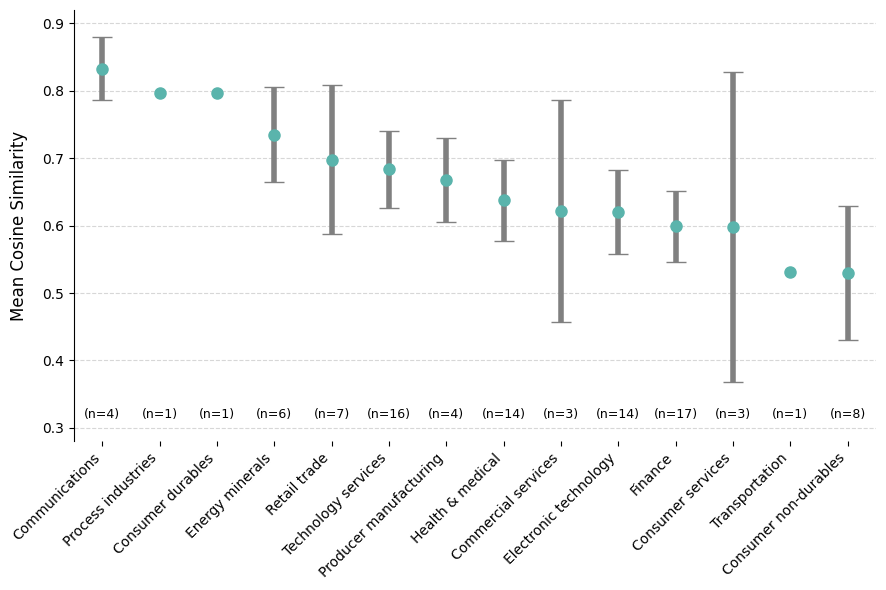

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# 1. Merge Health sectors
df_combined['Industry Sector'] = df_combined['Industry Sector'].replace({
    'Health Technology': 'Health & medical',
    'Health Services': 'Health & medical'
})

# 2. Compute statistics
grouped = df_combined.groupby("Industry Sector")["Cosine (Raw)"]
mean = grouped.mean()
std = grouped.std()
count = grouped.count()
stderr = std / np.sqrt(count)

# 3. Create and save summary DataFrame
summary_df = pd.DataFrame({
    "Industry Sector": mean.index,
    "Mean": mean.values,
    "Std": std.values,
    "Count": count.values,
    "StdErr": stderr.values
}).sort_values("Mean", ascending=False).reset_index(drop=True)

# Save as CSV
#summary_df.to_csv("/Users/wangseongpil/Downloads/cosine_summary_by_sector.csv", index=False)

# 4. Visualization (modified as point plot)
fig, ax = plt.subplots(figsize=(9, 6))
x = np.arange(len(summary_df))

# Display mean as point and error as bar
ax.errorbar(x, summary_df["Mean"], yerr=summary_df["StdErr"], fmt='o',
            color='#5AB4AC', ecolor='gray', elinewidth=4, capsize=7, markersize=8)

# Display sample size as text below data point
for xpos, mean_val, n,std_val in zip(x, summary_df["Mean"], summary_df["Count"],summary_df["StdErr"]):
    
    # if n!= 1: 
    #     ax.text(xpos, mean_val-std_val-0.03, f'n={n}', ha='center', va='top', fontsize=11)
    # else:
    #     ax.text(xpos, mean_val-0.03, f'n={n}', ha='center', va='top', fontsize=11)
    ax.text(xpos, 0.33, f'(n={n})', ha='center', va='top', fontsize=9)
    
# Axis style
ax.set_xticks(x)
ax.set_xticklabels(summary_df["Industry Sector"], rotation=45, ha='right')
ax.set_ylabel("Mean Cosine Similarity", labelpad=10, fontsize=12)
ax.set_ylim(0.28, 0.92)
ax.set_xlim(-0.5, len(summary_df) - 0.5)
ax.axhline(0, color='black', linewidth=0.7, linestyle='--', alpha=0.7)
ax.grid(axis='y', linestyle='--', alpha=0.5)

# Remove top and bottom spines (open borders)
sns.despine(ax=ax, top=True, bottom=True)

plt.tight_layout()
plt.savefig("/Users/wangseongpil/Downloads/cosine_by_sector_2_t?.png", dpi=300, bbox_inches='tight')
plt.show()


### - Visualization 1. overall similarity

In [46]:
df_combined

,Unnamed: 0,Col_0,Col_1,Col_2,Col_3,Col_4,Col_5,Col_6,Col_7,Col_8,Col_9,Col_10,Industry Sector,Col_12,Company,Cosine (Raw)
0,0.0,AAPL,Apple Inc.,United States,3.55 TUSD,236.00USD,−0.67%,1.47,37.45,6.30USD,−1.95%,0.42%,Electronic technology,Buy,Apple Inc.,0.368443
1,1.0,NVDA,NVIDIA Corporation,United States,2.94 TUSD,120.07USD,−3.67%,1.12,47.30,2.54USD,+235.19%,0.03%,Electronic technology,Strong buy,NVIDIA Corporation,0.888714
2,2.0,MSFT,Microsoft Corporation,United States,3.09 TUSD,415.06USD,+0.02%,1.28,33.43,12.42USD,+12.29%,0.74%,Technology services,Strong buy,Microsoft Corporation,0.604957
3,3.0,AMZN,"Amazon.com, Inc.",United States,2.5 TUSD,237.68USD,+1.30%,1.03,50.94,4.67USD,+143.64%,0.00%,Retail trade,Strong buy,"Amazon.com, Inc.",0.351706
4,4.0,GOOG,Alphabet Inc.,United States,2.51 TUSD,205.60USD,+1.47%,1.03,27.27,7.54USD,+44.53%,0.29%,Technology services,Buy,Alphabet Inc.,0.546462
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,95.0,NVDA,Boston Scientific Corporation,United States,2.94 TUSD,120.07USD,−3.67%,1.12,47.30,2.54USD,+235.19%,0.03%,Electronic technology,Strong buy,Boston Scientific Corporation,0.716168
96,96.0,SHOP,Shopify Inc.,Canada,167.44 BUSD,129.31USD,+0.75%,0.63,86.21,1.50USD,"+1,429.16%",0.00%,Technology services,Buy,Shopify Inc.,0.735308
97,97.0,BLK,"BlackRock, Inc.",United States,166.57 BUSD,"1,075.50USD",+0.37%,1.25,25.61,42.00USD,+15.01%,1.90%,Finance,Buy,"BlackRock, Inc.",0.500867
98,98.0,601398,"China Merchants Bank Co., Ltd.",China,311.81 BUSD,6.82CNY,+2.25%,1.14,—,—,—,6.60%,Finance,Buy,"China Merchants Bank Co., Ltd.",0.586872


✅ Placing logo at: x=0.01, y=0.95654480199643
✅ Placing logo at: x=0.0198989898989899, y=0.950056663053948
✅ Placing logo at: x=0.029797979797979796, y=0.9440290150909039
✅ Placing logo at: x=0.039696969696969696, y=0.9436767514648671
✅ Placing logo at: x=0.049595959595959596, y=0.9239236441724517
✅ Placing logo at: x=0.059494949494949496, y=0.9168326423998792
✅ Placing logo at: x=0.06939393939393938, y=0.9051328748787126
✅ Placing logo at: x=0.07929292929292929, y=0.9022223914810158
✅ Placing logo at: x=0.08919191919191918, y=0.8902061234240738
✅ Placing logo at: x=0.09909090909090908, y=0.8887141608277014
✅ Placing logo at: x=0.10898989898989898, y=0.8831244715346995
✅ Placing logo at: x=0.11888888888888888, y=0.8811666507341125
✅ Placing logo at: x=0.12878787878787878, y=0.8798578395836043
✅ Placing logo at: x=0.1386868686868687, y=0.879442047231003
✅ Placing logo at: x=0.1485858585858586, y=0.8785117882925817
✅ Placing logo at: x=0.15848484848484848, y=0.8701500149175272
✅ Placing 

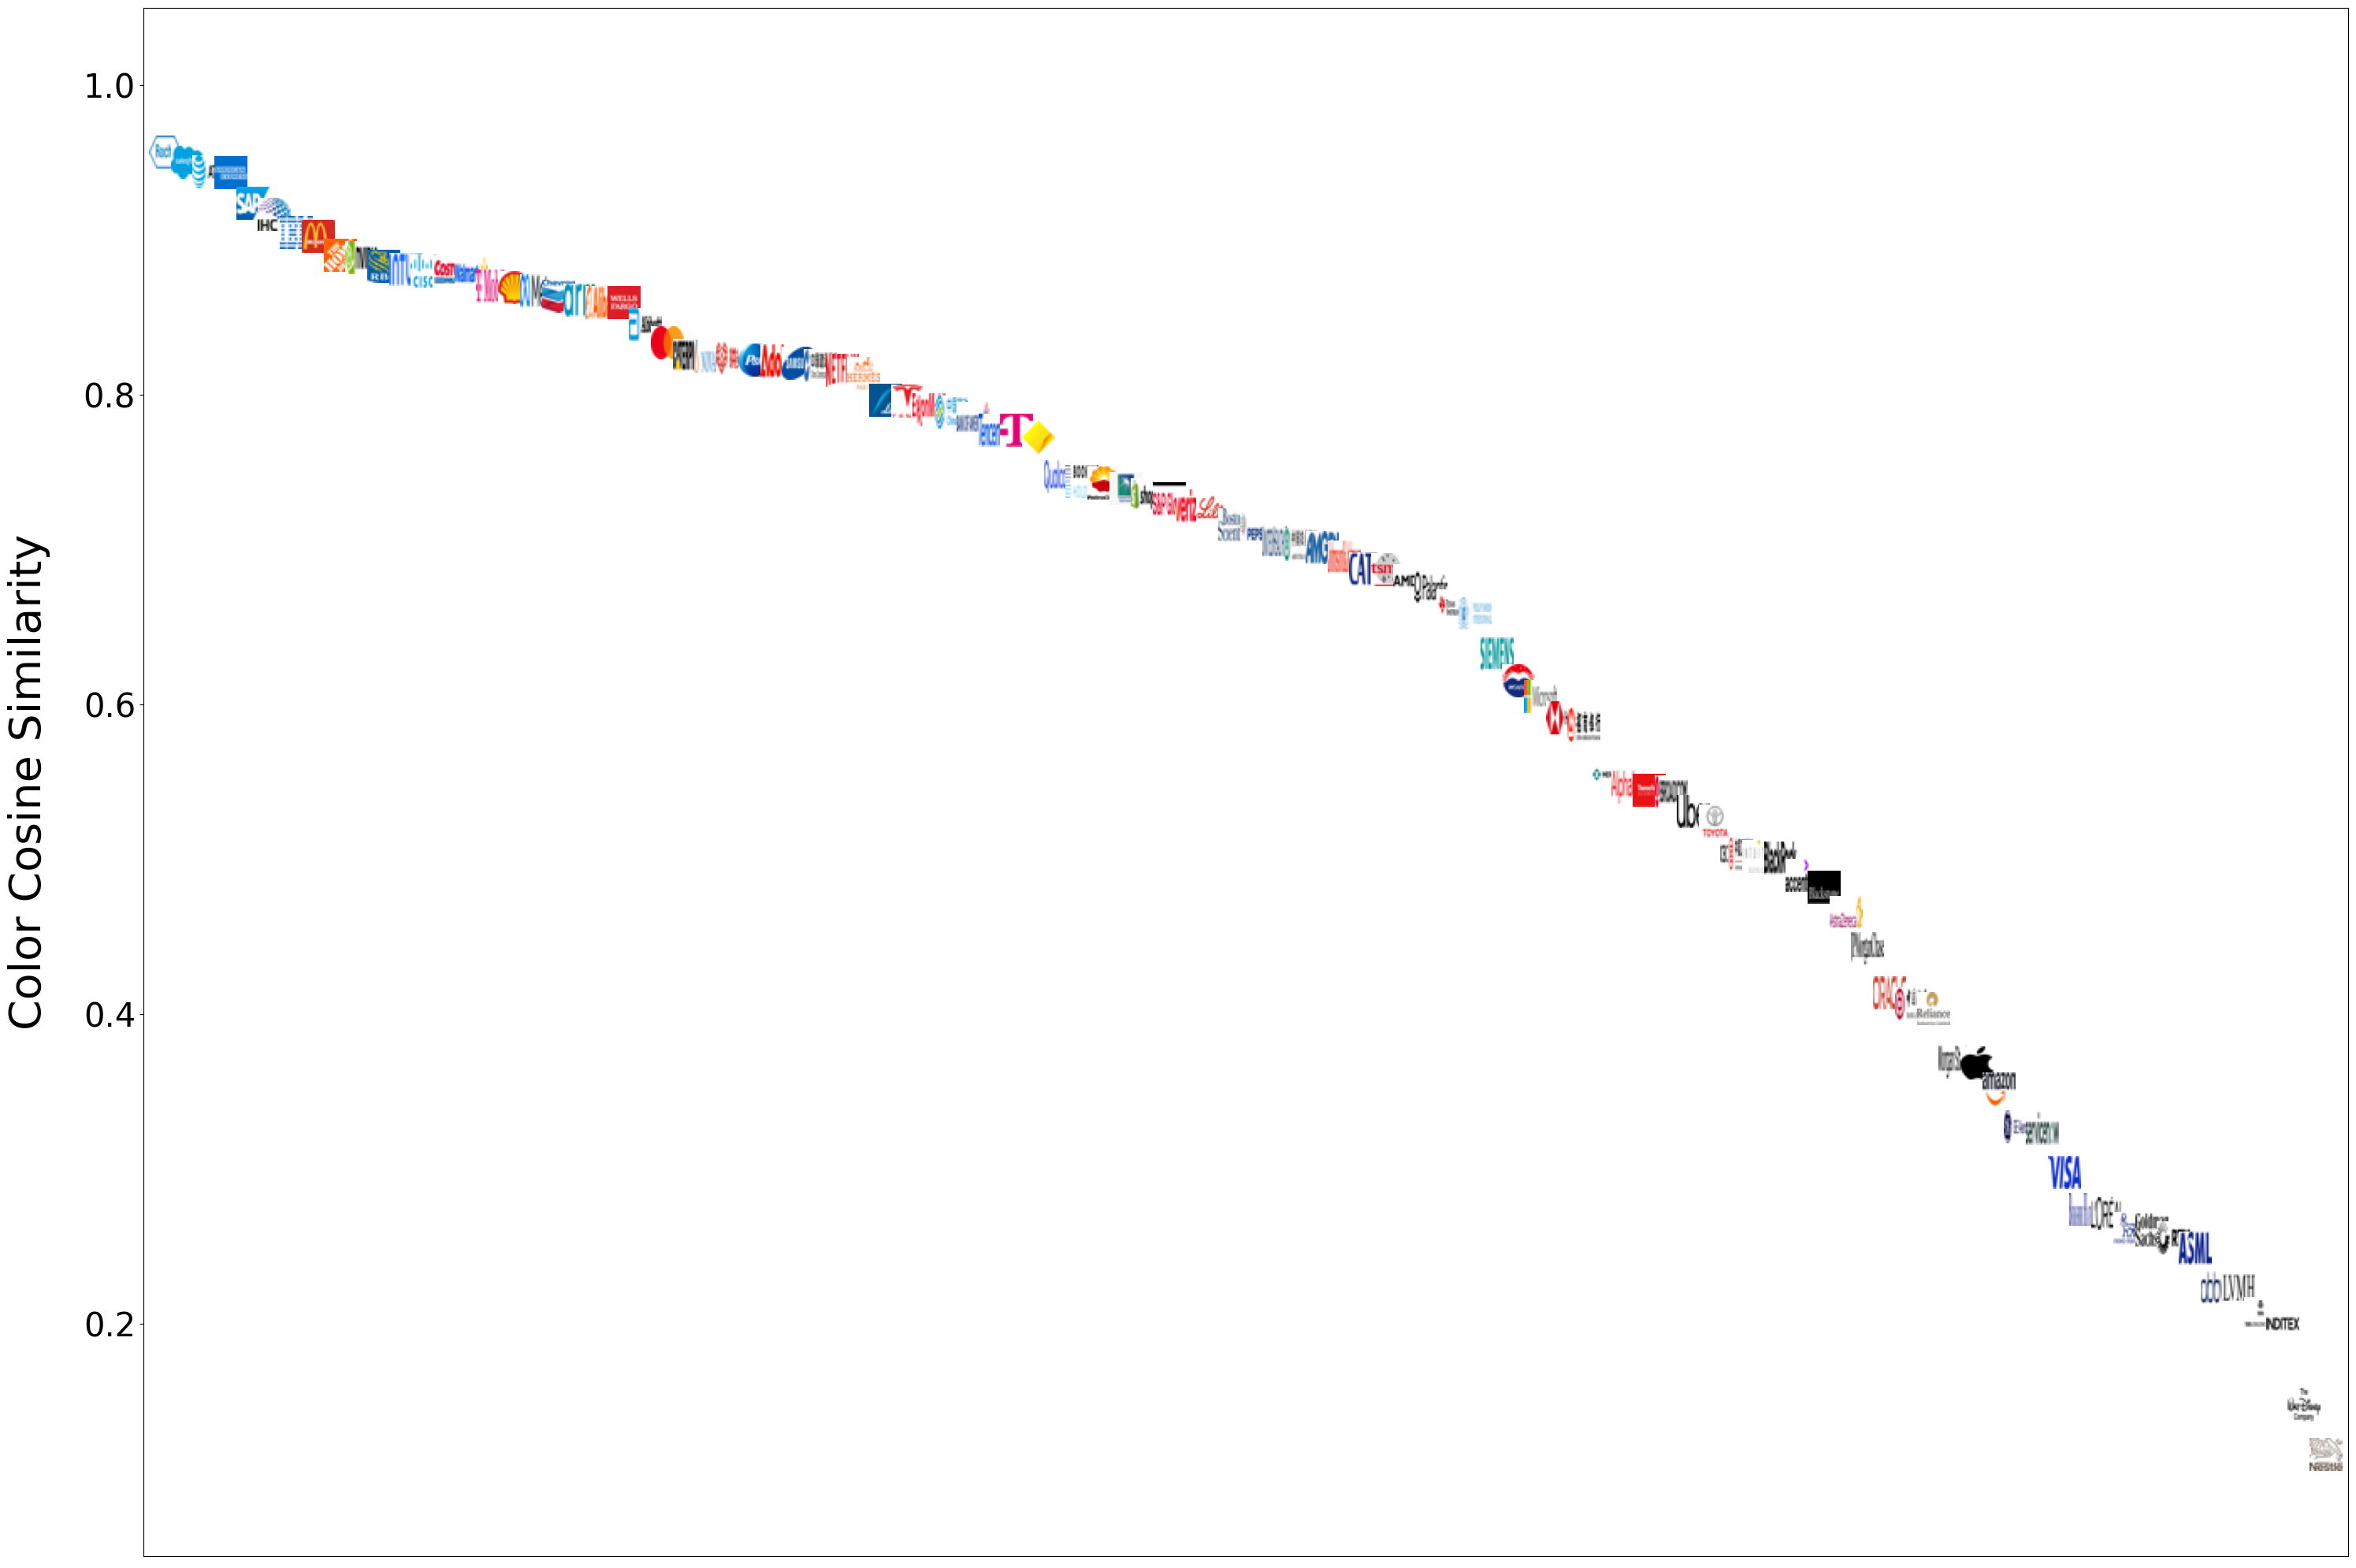

In [47]:
# ✅ Sorting Dataframe
df_sorted = df_combined.sort_values(by="Cosine (Raw)", ascending=False).reset_index(drop=True)

# Set graph size
fig, ax = plt.subplots(figsize=(30, 20))

# Normalize x-axis positions between 0 and 1
x_positions = np.linspace(0.01, 0.99, len(df_sorted))  # Normalize x-coordinates
y_values = df_sorted["Cosine (Raw)"].tolist()

# Logo image directory
logo_dir = "./company_logos"

# Retrieve the actual list of files in the folder
if os.path.exists(logo_dir):
    logo_files = set(os.listdir(logo_dir))  # Store existing files as a set
else:
    logo_files = set()

# Adjust logo size (20x20 pixels)
logo_size = (20, 20)

# Insert logos at each position based on y-axis values
for x, (company, y_value) in zip(x_positions, zip(df_sorted["Company"], y_values)):
    # Ensure minimum y-value (prevent values from being too small, set minimum to 0.02)
    #y_value = max(y_value, 0.02)

    # Use filename as is
    logo_filename = f"{company}.png"
    logo_path = os.path.join(logo_dir, logo_filename)

    # Display the logo only if the image file exists
    if logo_filename in logo_files:
        img = Image.open(logo_path).convert("RGBA")  # Handle transparent background

        # Convert transparent background to white
        background = Image.new("RGB", img.size, (255, 255, 255))
        img = Image.alpha_composite(background.convert("RGBA"), img).convert("RGB")

        # Resize to (20x20)
        img = img.resize(logo_size)

        # Place each logo using AnnotationBbox
        imagebox = OffsetImage(img, zoom=1.5)
        ab = AnnotationBbox(imagebox, (x, y_value), frameon=False, zorder=20)
        ax.add_artist(ab)

        print(f"✅ Placing logo at: x={x}, y={y_value}")  # Debugging output

# Remove x-axis (display only logos without company names)
ax.set_xticks([])  
ax.set_xticklabels([])
ax.set_yticks(np.linspace(-1, 1, 11))
ax.tick_params(axis='y', labelsize=30)

# Set labels
ax.set_ylabel("Color Cosine Similarity", fontsize=40, labelpad=30)
ax.set_ylim(0.05, 1.05)
ax.axhline(0, color='gray', linewidth=2, linestyle='--')  # 기준선 추가


# Save and show
plt.savefig("debug_output_new.png", dpi=300)
plt.tight_layout()
plt.show()


✅ Matched logos: 100 / 100


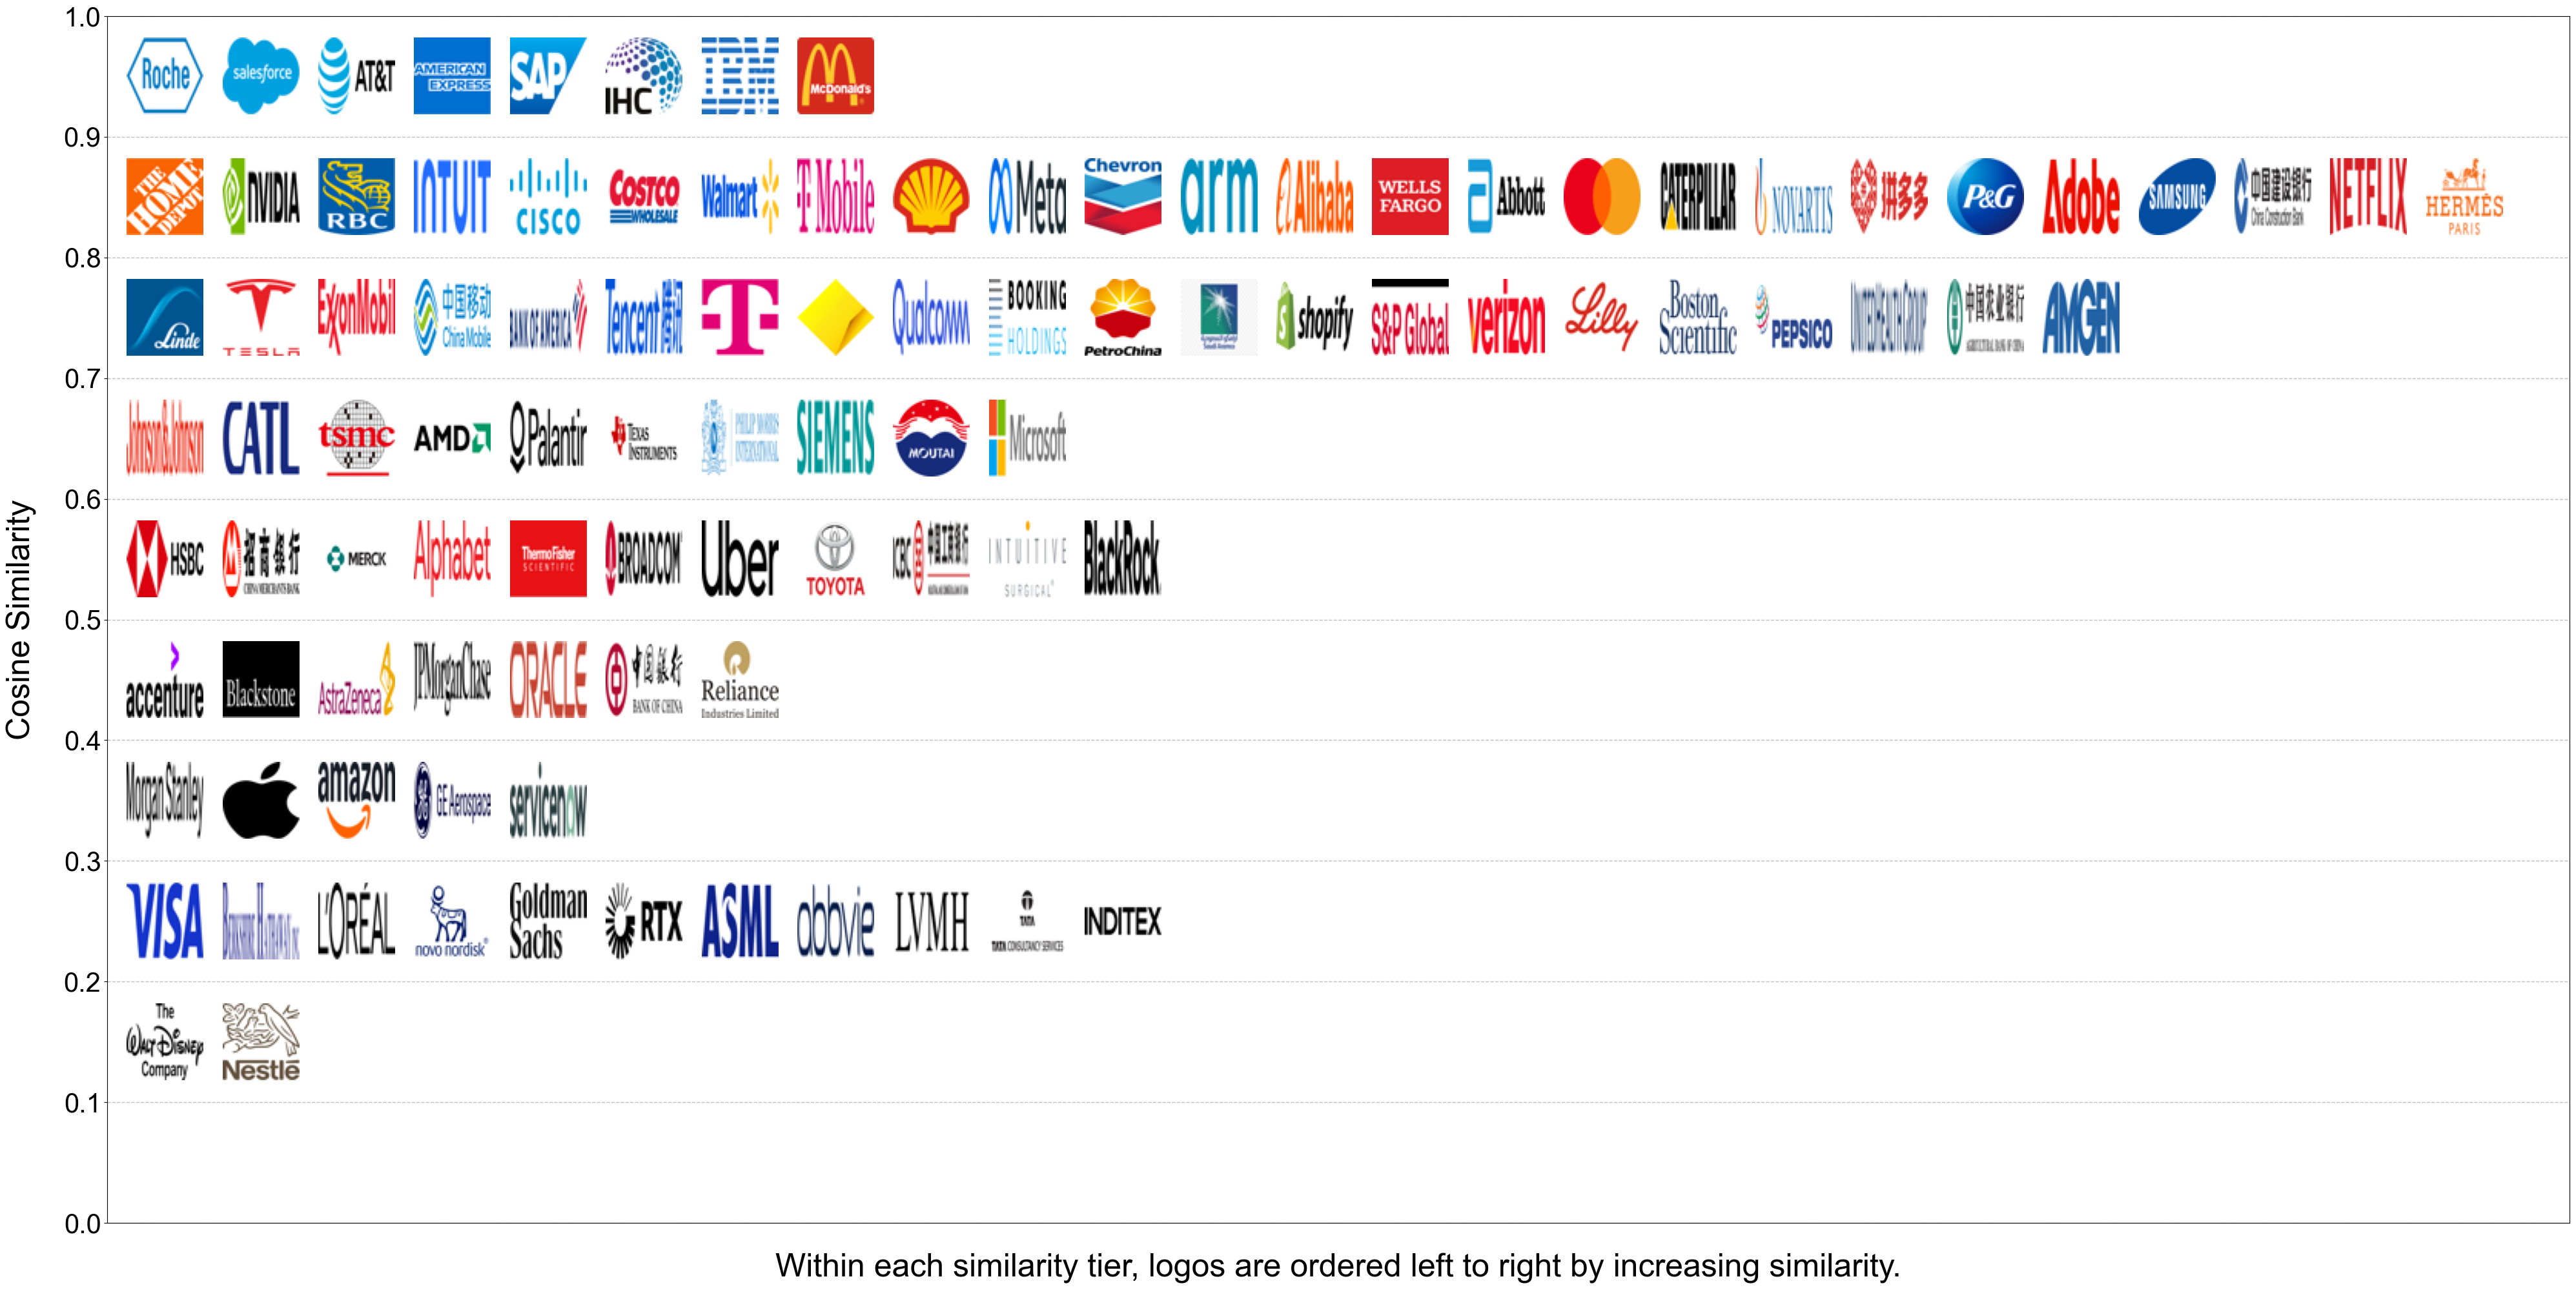

In [48]:
# Setting Font
plt.rcParams['font.family'] = 'Arial'

# 1. Prepare data
df_sorted = df_combined.sort_values(by="Cosine (Raw)", ascending=False).reset_index(drop=True)

bucket_edges = np.arange(0.0, 1.1, 0.1)
bucket_indices = np.digitize(df_sorted["Cosine (Raw)"], bucket_edges) - 1

# 2. Map logos
logo_dir = "./company_logos"
logo_files = os.listdir(logo_dir) if os.path.exists(logo_dir) else []

logo_file_stems_normalized = {
    unicodedata.normalize("NFC", Path(f).stem): f
    for f in logo_files
    if Path(f).suffix.lower() in [".png", ".jpg", ".jpeg", ".webp"]
}

matched_files = {}
missing_logos = []

for company in df_sorted["Company"]:
    normalized_name = unicodedata.normalize("NFC", company)
    if normalized_name in logo_file_stems_normalized:
        matched_files[company] = logo_file_stems_normalized[normalized_name]
    else:
        missing_logos.append(company)

print(f"✅ Matched logos: {len(matched_files)} / {len(df_sorted)}")
if missing_logos:
    print("❌ Missing logos:")
    for name in missing_logos:
        print(f"  - {name}")

# 3. Set logo placement
spacing = 0.005
x_start = 0.003
logo_size = (50, 50)
bucket_counts = {i: 0 for i in range(10)}

# Set width with margin, keep height unchanged
fig, ax = plt.subplots(figsize=(40, 20))

# 4. Place logos
for i, row in df_sorted.iterrows():
    company = row["Company"]
    bucket = bucket_indices[i]

    if company not in matched_files:
        continue

    if 0 <= bucket < 10:
        count = bucket_counts[bucket]
        x = x_start + spacing * count
        y = 0.05 + 0.1 * bucket
        bucket_counts[bucket] += 1

        logo_path = os.path.join(logo_dir, matched_files[company])
        try:
            img = Image.open(logo_path).convert("RGBA")
            background = Image.new("RGB", img.size, (255, 255, 255))
            img = Image.alpha_composite(background.convert("RGBA"), img).convert("RGB")
            img = img.resize(logo_size)

            imagebox = OffsetImage(img, zoom=1.7)
            ab = AnnotationBbox(imagebox, (x, y), frameon=False, zorder=20)
            ax.add_artist(ab)
        except Exception as e:
            print(f"❌ Failed to process {company}: {e}")

# 5. Set x-axis range dynamically
max_count = max(bucket_counts.values())
x_end = x_start + spacing * (max_count + 0.1)
ax.set_xlim(0.0, x_end)

# 6. Configure visual elements
ax.set_yticks(np.arange(0.0, 1.1, 0.1))
ax.set_ylim(0.00, 1.00)
ax.set_ylabel("Cosine Similarity", fontsize=36, labelpad=30)
ax.tick_params(axis='y', labelsize=30)
ax.set_xticks([])
ax.set_xticklabels([])
ax.grid(axis='y', linestyle='--', linewidth=1, color='gray', alpha=0.5)

# 7. Explanatory text
ax.text(0.5, -0.025,
        "Within each similarity tier, logos are ordered left to right by increasing similarity.",
        fontsize=36, ha='center', va='top', transform=ax.transAxes)

# 8. Save and display
plt.tight_layout()
plt.savefig("figure_logos_by_similarity_final.png", dpi=300)
plt.show()


### - Visualization 2. Individual similarity using radar charts

In [106]:
def plot_radar_chart(brand):
    # List of all colors
    all_colors = ['red', 'orange', 'yellow', 'green', 'blue', 'purple', 'pink', 'black', 'grey', 'white']
    
    # Generate color vectors for logos and screenshots
    logo_vec = np.array([logo_colors.get(brand, {}).get(color, 0) for color in all_colors])
    screenshot_vec = np.array([screenshot_colors.get(brand, {}).get(color, 0) for color in all_colors])

    # Fixed minimum value
    min_value = -0.1
    max_value = float(np.ceil(max(logo_vec.max(), screenshot_vec.max())))

    # Y-axis ticks (e.g., 0.0, 0.2, ..., 1.0)
    tick_step = 0.2
    tick_range = np.arange(0, max_value + tick_step, tick_step)
    str_range_list = [f"{i:.1f}" for i in tick_range]
    
    # Configure radar chart
    angles = np.linspace(0, 2 * np.pi, len(all_colors), endpoint=False).tolist()
    angles += angles[:1]  # Close the radar chart
    logo_vec = np.concatenate((logo_vec, [logo_vec[0]]))
    screenshot_vec = np.concatenate((screenshot_vec, [screenshot_vec[0]]))
    
    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
    ax.plot(angles, logo_vec, color="black", linestyle="-", linewidth=2, label="Logo")
    ax.plot(angles, screenshot_vec, color="black", linestyle="--", linewidth=2, label="Screenshot")
    
    # Fill radar chart background with transparent color sectors from 0 (not from min_value)
    rotated_angles = [(angle - np.pi / 10) % (2 * np.pi) for angle in angles[:-1]]
    rotated_angles += rotated_angles[:1]
    
    for i in range(len(all_colors)):
        angle1 = rotated_angles[i]
        angle2 = rotated_angles[(i + 1) % len(all_colors)]
        color = mcolors.to_rgba(all_colors[i], alpha=0.2)
        #ax.fill_betweenx(np.linspace(0, max_value, 100), angle1, angle2, color=color)
        ax.fill_betweenx(np.linspace(0, max_value * 1.2, 100), angle1, angle2, color=color)

    # Set axis ticks and labels
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(all_colors, fontsize=10)
    ax.xaxis.set_tick_params(pad=10)

    ax.set_ylim(min_value, max_value * 1.1)
    ax.set_yticks(tick_range)
    ax.set_yticklabels(str_range_list)

    # Title and legend
    ax.set_title(f"{brand}", fontsize=20, pad=10)
    ax.legend(fontsize=13, bbox_to_anchor=(1.15, 1.1))
    
    # Save radar chart
    plt.savefig(f"{brand}_radar.png")
    plt.show()


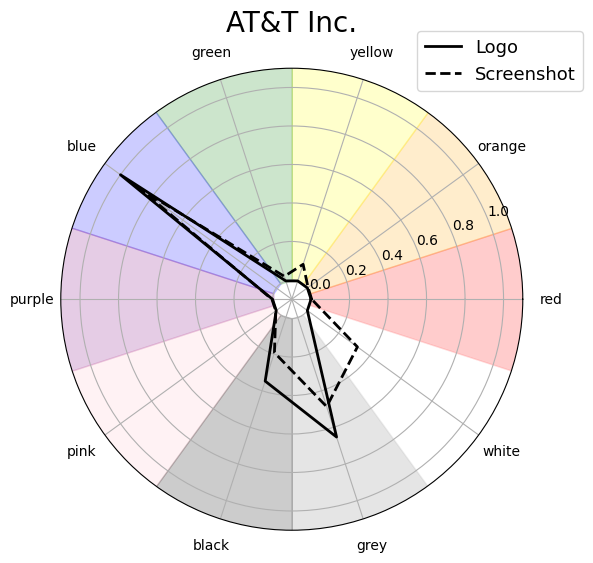

In [108]:
# Run the function for a specific brand (e.g., GE Aerospace)
plot_radar_chart("AT&T Inc.")

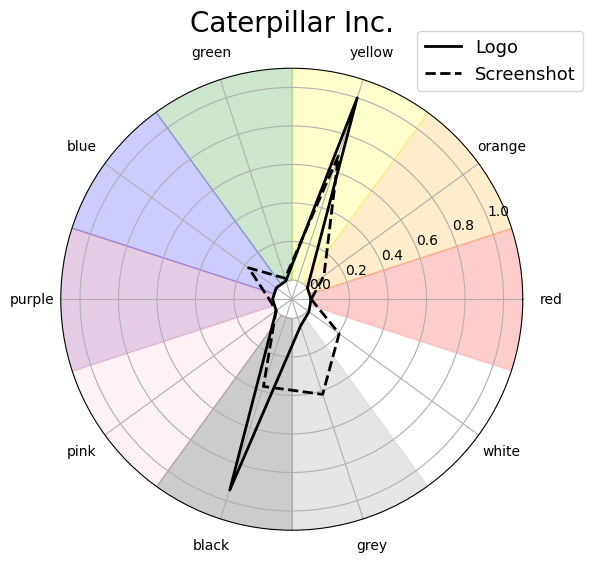

In [109]:
# Run the function for a specific brand (e.g., GE Aerospace)
plot_radar_chart("Caterpillar Inc.")

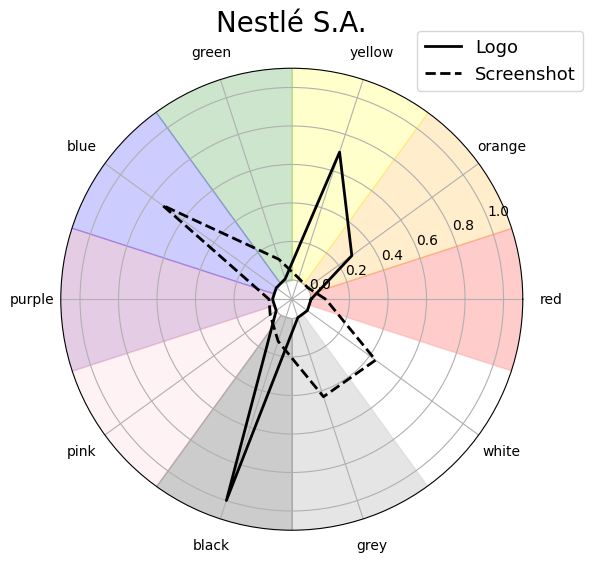

In [110]:
plot_radar_chart("Nestlé S.A.")

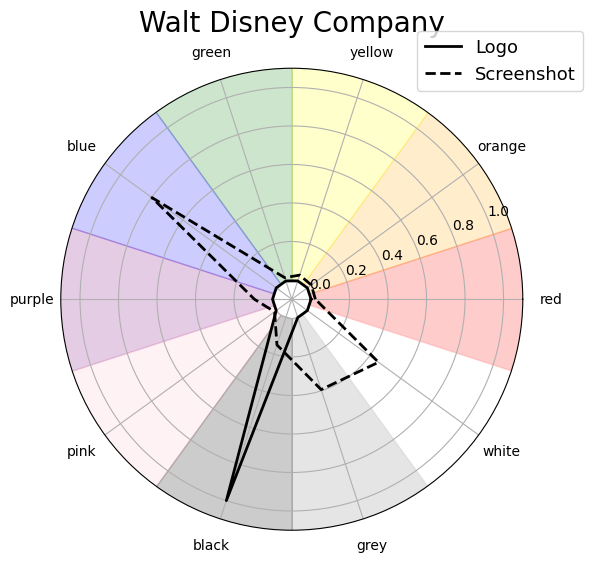

In [111]:
plot_radar_chart("Walt Disney Company")